In [1]:
# import dependencies
import pandas as pd
import geopandas as gpd
import fiona
import matplotlib.pyplot as plt


## Census Map Data

In [2]:
# open shapefile
fp = "../data/raw/census_shp/tl_2025_50_cousub.shp"
gdf_fed = gpd.read_file(fp)
gdf_fed.head()

,STATEFP,COUNTYFP,COUSUBFP,COUSUBNS,GEOID,GEOIDFQ,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,50,015,23500,01462088,5001523500,0600000US5001523500,Eden,Eden town,43,T1,G4040,A,162970286,2552928,+44.7144313,-072.5394153,"POLYGON ((-72.66139 44.70192, -72.66084 44.702..."
1,50,025,48400,01462159,5002548400,0600000US5002548400,Newfane,Newfane town,43,T1,G4040,A,102981054,697246,+42.9727535,-072.7040391,"POLYGON ((-72.7755 42.92638, -72.77376 42.9292..."
2,50,025,60250,01462189,5002560250,0600000US5002560250,Rockingham,Rockingham town,43,T1,G4040,A,107252397,2011216,+43.1704749,-072.5065934,"POLYGON ((-72.55798 43.12776, -72.55798 43.128..."
3,50,025,81400,01462253,5002581400,0600000US5002581400,Westminster,Westminster town,43,T1,G4040,A,116613918,669527,+43.0746825,-072.5080568,"POLYGON ((-72.58564 43.02324, -72.58491 43.027..."
4,50,025,84850,01462265,5002584850,0600000US5002584850,Windham,Windham town,43,T1,G4040,A,67581474,211573,+43.1738019,-072.7013584,"POLYGON ((-72.77335 43.1539, -72.77256 43.1547..."


In [3]:
gdf_fed.columns

Index(['STATEFP', 'COUNTYFP', 'COUSUBFP', 'COUSUBNS', 'GEOID', 'GEOIDFQ',
       'NAME', 'NAMELSAD', 'LSAD', 'CLASSFP', 'MTFCC', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry'],
      dtype='object')

In [4]:
len(gdf_fed)

256

Length is correct

In [5]:
gdf_fed.NAMELSAD.unique()

array(['Eden town', 'Newfane town', 'Rockingham town', 'Westminster town',
       'Windham town', 'Brookline town', 'Dover town', 'Grafton town',
       'Guilford town', 'Bradford town', 'Corinth town', 'Fairlee town',
       'Orange town', 'Randolph town', 'Strafford town', 'Putney town',
       'Vernon town', 'Berkshire town', 'Enosburgh town',
       'Fairfield town', 'Fletcher town', 'Panton town', 'Ripton town',
       'Shoreham town', 'Starksboro town', 'Vergennes city',
       'Groton town', 'Hardwick town', 'Montpelier city',
       'Northfield town', 'Roxbury town', 'Waitsfield town',
       'Chittenden town', 'Sandgate town', 'Williamstown town',
       'Ira town', 'Killington town', 'Mendon town', 'Mount Holly town',
       'Wolcott town', 'Belvidere town', 'Cambridge town',
       'Guildhall town', 'Lewis town', 'Norton town', 'Victory town',
       "Warren's gore", "Warner's grant", 'Morristown town',
       'Averill town', "Avery's gore", 'Derby town', 'Warren town',
    

In [6]:
# unique values in the last last word of the column NAMELSAD
gdf_fed['NAMELSAD'].apply(lambda x: x.split()[-1]).value_counts()

NAMELSAD
town     242
city      10
gore       3
grant      1
Name: count, dtype: int64

In [7]:
# display all gdf.NAME where gdf['NAMELSAD'].apply(lambda x: x.split()[-1]).value_counts() = city
gdf_fed[gdf_fed['NAMELSAD'].apply(lambda x: x.split()[-1]) == 'city']['NAME']

25            Vergennes
28           Montpelier
77           St. Albans
86             Winooski
134             Newport
145      Essex Junction
152             Rutland
189          Burlington
191    South Burlington
218               Barre
Name: NAME, dtype: object

In [8]:
# check projection
print(gdf_fed.crs)

# convert to WGS84
gdf_fed = gdf_fed.to_crs("EPSG:4326")

# check projection
print(gdf_fed.crs)

EPSG:4269
EPSG:4326


## Vermont State Map Data

In [9]:
# open VT shapefile
fp_vt = "../data/raw/VT_shp/FS_VCGI_OPENDATA_Boundary_BNDHASH_poly_towns_SP_v1.shp"
gdf_vt = gpd.read_file(fp_vt)
gdf_vt.head()

,FIPS6,TOWNNAME,TOWNNAMEMC,CNTY,TOWNGEOID,geometry
0,9030,CANAAN,Canaan,9,5000911800,"POLYGON ((581554.37 279748.95, 581552.52 27972..."
1,11040,FRANKLIN,Franklin,11,5001127100,"POLYGON ((473019.044 279659.74, 473609.711 279..."
2,11015,BERKSHIRE,Berkshire,11,5001105425,"POLYGON ((478712.666 279552.468, 480438.141 27..."
3,11050,HIGHGATE,Highgate,11,5001133025,"POLYGON ((460860.097 279521.625, 460904.581 27..."
4,11060,RICHFORD,Richford,11,5001159125,"POLYGON ((494553.307 278836.192, 495632.799 27..."


In [10]:
gdf_vt.columns

Index(['FIPS6', 'TOWNNAME', 'TOWNNAMEMC', 'CNTY', 'TOWNGEOID', 'geometry'], dtype='object')

In [11]:
# check projection
print(gdf_vt.crs)

# convert to WGS84
gdf_vt = gdf_vt.to_crs("EPSG:4326")

# check projection
print(gdf_vt.crs)

PROJCS["NAD83 / Vermont",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",42.5],PARAMETER["central_meridian",-72.5],PARAMETER["scale_factor",0.999964285714286],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
EPSG:4326


In [12]:
len(gdf_vt)

256

Length matches

In [13]:
# check if gdf_fed.NAME matches gdf_vt.TOWNNAMEMC
matching_names = gdf_fed['NAME'].isin(gdf_vt['TOWNNAMEMC'])
print(f"Number of matching names: {matching_names.sum()}")
# display the matching names
print(gdf_fed['NAME'][matching_names])

Number of matching names: 242
0              Eden
1           Newfane
2        Rockingham
3       Westminster
4           Windham
           ...     
251        Thetford
252         Topsham
253       Tunbridge
254        Vershire
255    West Fairlee
Name: NAME, Length: 242, dtype: object


In [14]:
# print names not in matching_names
print(gdf_fed['NAME'][~matching_names])

46          Warren's
47          Warner's
50           Avery's
62             Barre
77        St. Albans
80        St. Albans
87             Buels
101       St. George
134          Newport
135          Newport
152          Rutland
211          Rutland
218            Barre
249    St. Johnsbury
Name: NAME, dtype: object


In [15]:
unmatched_vt = ~gdf_vt['TOWNNAMEMC'].isin(gdf_fed['NAME'])
print(gdf_vt['TOWNNAMEMC'][unmatched_vt])

13          Avery's Gore
14         Warren's Gore
15        Warner's Grant
24     Saint Albans Town
32     Saint Albans City
74       Saint Johnsbury
81          Saint George
100           Barre Town
101           Buels Gore
103           Barre City
207         Rutland City
228         Newport Town
231         Newport City
251         Rutland Town
Name: TOWNNAMEMC, dtype: object


Pretty easy to clean up

In [16]:
# check if gdf_fed.GEOID matches gdf_vt.TOWNGEOID
matching_geoids = gdf_fed['GEOID'].isin(gdf_vt['TOWNGEOID'])
print(f"Number of matching GEOIDs: {matching_geoids.sum()}")
# print GEOIDs not in matching_geoids
print(gdf_fed['GEOID'][~matching_geoids])
# print GEOIDs in gdf_vt not in gdf_fed
print(gdf_vt['TOWNGEOID'][~gdf_vt['TOWNGEOID'].isin(gdf_fed['GEOID'])])

Number of matching GEOIDs: 256
Series([], Name: GEOID, dtype: object)
Series([], Name: TOWNGEOID, dtype: object)


Good match

In [17]:
# calculate overlap ratio for matching GEOIDs
# 1.0 is a perfect match
for idx, row in gdf_fed.iterrows():
    vt_row = gdf_vt[gdf_vt['TOWNGEOID'] == row['GEOID']]
    if not vt_row.empty:
        intersection = row['geometry'].intersection(vt_row.iloc[0]['geometry'])
        overlap_ratio = intersection.area / row['geometry'].area
        print(f"{row['NAME']} overlap ratio: {overlap_ratio:.2f}")

Eden overlap ratio: 1.00
Newfane overlap ratio: 1.00
Rockingham overlap ratio: 1.00
Westminster overlap ratio: 1.00
Windham overlap ratio: 1.00
Brookline overlap ratio: 1.00
Dover overlap ratio: 1.00
Grafton overlap ratio: 1.00
Guilford overlap ratio: 1.00
Bradford overlap ratio: 1.00
Corinth overlap ratio: 1.00
Fairlee overlap ratio: 1.00
Orange overlap ratio: 1.00
Randolph overlap ratio: 1.00
Strafford overlap ratio: 1.00
Putney overlap ratio: 1.00
Vernon overlap ratio: 1.00
Berkshire overlap ratio: 1.00
Enosburgh overlap ratio: 1.00
Fairfield overlap ratio: 1.00
Fletcher overlap ratio: 1.00
Panton overlap ratio: 1.00
Ripton overlap ratio: 1.00
Shoreham overlap ratio: 1.00
Starksboro overlap ratio: 1.00
Vergennes overlap ratio: 1.00
Groton overlap ratio: 1.00
Hardwick overlap ratio: 1.00
Montpelier overlap ratio: 1.00
Northfield overlap ratio: 1.00
Roxbury overlap ratio: 1.00
Waitsfield overlap ratio: 1.00
Chittenden overlap ratio: 1.00
Sandgate overlap ratio: 1.00
Williamstown overl

Beautiful

Looks like I can combine state and fed maps with minimal cleaning

## FEMA National Flood Hazard Layer

In [18]:
# open FEMA NFHL geodatabase
# import fiona

gdb_path = "../data/raw/FEMA_NFHL/NFHL_50_20241002.gdb"
layers = fiona.listlayers(gdb_path)
print(layers)

['S_GEN_STRUCT', 'S_WTR_AR', 'S_STN_START', 'S_XS', 'S_TRNSPORT_LN', 'S_FLD_HAZ_AR', 'L_PAN_REVIS', 'S_BASE_INDEX', 'S_LEVEE', 'S_FLD_HAZ_LN', 'S_LOMR', 'L_SOURCE_CIT', 'S_PROFIL_BASLN', 'L_XS_ELEV', 'S_WTR_LN', 'S_POL_AR', 'S_LABEL_LD', 'STUDY_INFO', 'L_COMM_INFO', 'S_BFE', 'S_FIRM_PAN', 'S_LABEL_PT']


S_FLD_HAZ_AR - flood hazard layer

In [19]:
gdf_flood = gpd.read_file(gdb_path, layer="S_FLD_HAZ_AR")
print(gdf_flood.head())

c:\Users\johbr\anaconda3\envs\dev\lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


  DFIRM_ID VERSION_ID    FLD_AR_ID STUDY_TYP FLD_ZONE ZONE_SUBTY SFHA_TF  \
0   500234    1.1.1.0  500234_7875        NP        A       None       T   
1   500234    1.1.1.0  500234_7877        NP        A       None       T   
2   500237    1.1.1.0  500237_6480        NP        A       None       T   
3   500237    1.1.1.0  500237_7878        NP        A       None       T   
4   500237    1.1.1.0  500237_6482        NP        A       None       T   

   STATIC_BFE V_DATUM   DEPTH  ... AR_REVERT  AR_SUBTRV BFE_REVERT DEP_REVERT  \
0     -9999.0    None -9999.0  ...      None       None    -9999.0    -9999.0   
1     -9999.0    None -9999.0  ...      None       None    -9999.0    -9999.0   
2     -9999.0    None -9999.0  ...      None       None    -9999.0    -9999.0   
3     -9999.0    None -9999.0  ...      None       None    -9999.0    -9999.0   
4     -9999.0    None -9999.0  ...      None       None    -9999.0    -9999.0   

  DUAL_ZONE   SOURCE_CIT                                

In [20]:
print(gdf_flood.columns)

Index(['DFIRM_ID', 'VERSION_ID', 'FLD_AR_ID', 'STUDY_TYP', 'FLD_ZONE',
       'ZONE_SUBTY', 'SFHA_TF', 'STATIC_BFE', 'V_DATUM', 'DEPTH', 'LEN_UNIT',
       'VELOCITY', 'VEL_UNIT', 'AR_REVERT', 'AR_SUBTRV', 'BFE_REVERT',
       'DEP_REVERT', 'DUAL_ZONE', 'SOURCE_CIT', 'GFID', 'SHAPE_Length',
       'SHAPE_Area', 'geometry'],
      dtype='object')


In [21]:
len(gdf_flood)

7591

In [22]:
print(gdf_flood["FLD_ZONE"].unique())

['A' 'AE' 'X' 'AH' 'AO' 'AREA NOT INCLUDED' 'D' 'OPEN WATER']


The A's are high-risk flood zones.

In [23]:
print(gdf_flood["FLD_ZONE"].value_counts())

FLD_ZONE
X                    3605
AE                   3156
A                     816
AH                      4
AO                      3
D                       3
OPEN WATER              3
AREA NOT INCLUDED       1
Name: count, dtype: int64


In [24]:
# check projection
print(gdf_flood.crs)

# convert to WGS84
gdf_flood = gdf_flood.to_crs(epsg=4326)

# check the conversion
print(gdf_flood.crs)

EPSG:4269
EPSG:4326


In [25]:
print(gdf_flood.geometry.type.value_counts())
print(gdf_flood.shape)

MultiPolygon    7591
Name: count, dtype: int64
(7591, 23)


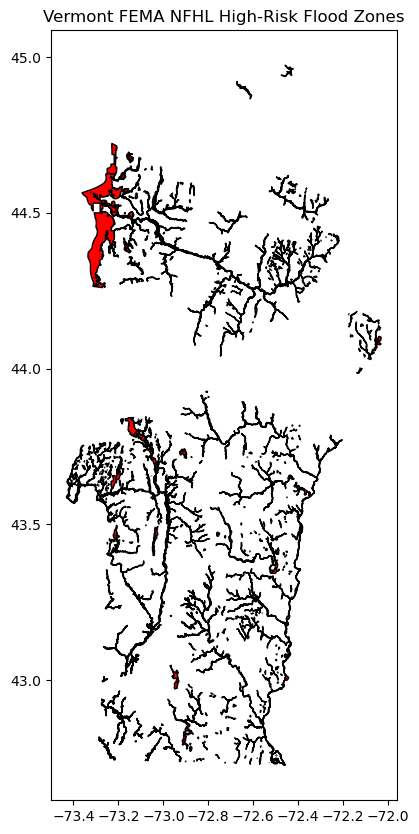

In [26]:
# plot high-risk zones (AE, A, AH, AO)
high_risk = gdf_flood[gdf_flood["FLD_ZONE"].isin(["AE", "A", "AH", "AO"])]
high_risk.plot(figsize=(10, 10), color="red", edgecolor="black")
plt.title("Vermont FEMA NFHL High-Risk Flood Zones")
plt.show()

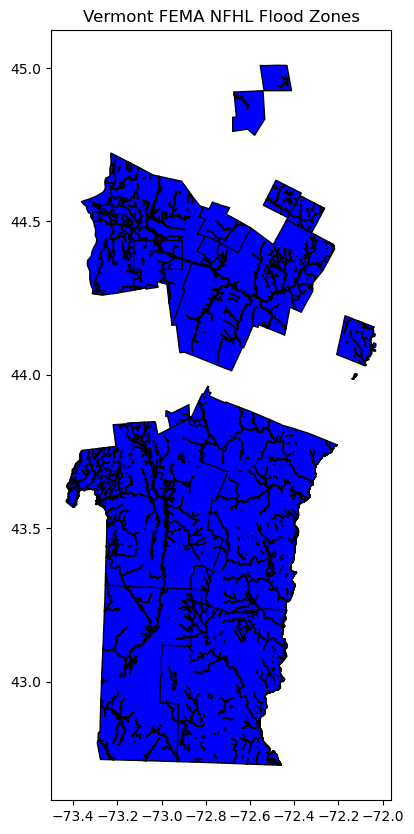

In [27]:
gdf_flood.plot(figsize=(10, 10), color="blue", edgecolor="black")
plt.title("Vermont FEMA NFHL Flood Zones")
plt.show()

Half the state is missing NFHL coverage.

In [28]:
# see how much of each town is in a high-risk flood zone
high_risk = gdf_flood[gdf_flood["FLD_ZONE"].isin(["AE", "A", "AH", "AO"])]
results = []
for idx, town in gdf_vt.iterrows():
    # Intersection of town with high-risk flood zones
    intersection = high_risk.intersection(town.geometry)
    flood_area = intersection.area.sum()
    town_area = town.geometry.area
    percent = (flood_area / town_area) * 100
    results.append({
        "TOWNNAME": town["TOWNNAME"],
        "percent_high_risk": percent
    })

df_results = pd.DataFrame(results)
df_results

c:\Users\johbr\anaconda3\envs\dev\lib\site-packages\shapely\set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)
C:\Users\johbr\AppData\Local\Temp\ipykernel_35700\529579426.py:7: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  flood_area = intersection.area.sum()


,TOWNNAME,percent_high_risk
0,CANAAN,0.000000
1,FRANKLIN,0.000000
2,BERKSHIRE,0.000000
3,HIGHGATE,0.000000
4,RICHFORD,0.000000
...,...,...
251,RUTLAND TOWN,10.027052
252,MENDON,0.997533
253,CLARENDON,10.163158
254,LUDLOW,3.238637


In [29]:
# Spatial join: which towns intersect flood polygons
joined = gpd.sjoin(gdf_vt, high_risk, how="left", predicate="intersects")
# check results
print(joined.head())
print(joined["FLD_ZONE"].value_counts(dropna=False))

   FIPS6   TOWNNAME TOWNNAMEMC  CNTY   TOWNGEOID  \
0   9030     CANAAN     Canaan     9  5000911800   
1  11040   FRANKLIN   Franklin    11  5001127100   
2  11015  BERKSHIRE  Berkshire    11  5001105425   
3  11050   HIGHGATE   Highgate    11  5001133025   
4  11060   RICHFORD   Richford    11  5001159125   

                                            geometry  index_right DFIRM_ID  \
0  POLYGON ((-71.46539 45.01322, -71.46541 45.013...          NaN      NaN   
1  POLYGON ((-72.84231 45.0166, -72.83481 45.0164...          NaN      NaN   
2  POLYGON ((-72.77007 45.01582, -72.74818 45.015...          NaN      NaN   
3  POLYGON ((-72.99655 45.01479, -72.99599 45.014...          NaN      NaN   
4  POLYGON ((-72.56909 45.00968, -72.5554 45.0080...          NaN      NaN   

  VERSION_ID FLD_AR_ID  ... VEL_UNIT AR_REVERT AR_SUBTRV BFE_REVERT  \
0        NaN       NaN  ...      NaN       NaN       NaN        NaN   
1        NaN       NaN  ...      NaN       NaN       NaN        NaN   
2    

So, 95 towns have no high risk flood zones (and probably no flood zone data at all - from FEMA).

But the spatial join works!

## American Community Survey

In [30]:
# check acs csv files for match to fips codes, skip first row
df_vehicle = pd.read_csv('../data/raw/acs/household_vehicles/ACSDT5Y2024.B08201-Data.csv', skiprows=1)
df_income = pd.read_csv('../data/raw/acs/median_household_income/ACSDT5Y2024.B19013-Data.csv', skiprows=1)
df_built = pd.read_csv('../data/raw/acs/median_year_structure_built/ACSDT5Y2024.B25035-Data.csv', skiprows=1)
df_owner_renter = pd.read_csv('../data/raw/acs/owner_renter/ACSDT5Y2024.B25003-Data.csv', skiprows=1)
df_sex_by_age = pd.read_csv('../data/raw/acs/sex_by_age/ACSDT5Y2024.B01001-Data.csv', skiprows=1)

In [31]:
df_sex_by_age["GEOID"] = df_sex_by_age["Geography"].str[-10:]
df_owner_renter["GEOID"] = df_owner_renter["Geography"].str[-10:]
df_vehicle["GEOID"] = df_vehicle["Geography"].str[-10:]
df_income["GEOID"] = df_income["Geography"].str[-10:]
df_built["GEOID"] = df_built["Geography"].str[-10:]

In [32]:
df_built

,Geography,Geographic Area Name,Estimate!!Median year structure built,Margin of Error!!Median year structure built,Unnamed: 4,GEOID
0,0600000US5000100325,"Addison town, Addison County, Vermont",1980,6,NaN,5000100325
1,0600000US5000108575,"Bridport town, Addison County, Vermont",1978,6,NaN,5000108575
2,0600000US5000109025,"Bristol town, Addison County, Vermont",1976,5,NaN,5000109025
3,0600000US5000116000,"Cornwall town, Addison County, Vermont",1976,7,NaN,5000116000
4,0600000US5000126300,"Ferrisburgh town, Addison County, Vermont",1968,6,NaN,5000126300
...,...,...,...,...,...,...
251,0600000US5002777500,"Weathersfield town, Windsor County, Vermont",1978,4,NaN,5002777500
252,0600000US5002782000,"Weston town, Windsor County, Vermont",1969,7,NaN,5002782000
253,0600000US5002783050,"West Windsor town, Windsor County, Vermont",1980,3,NaN,5002783050
254,0600000US5002784925,"Windsor town, Windsor County, Vermont",1945,7,NaN,5002784925


In [33]:
# check if gdf_fed.GEOID matches acs GEOID's
matching_geoids = gdf_fed["GEOID"].isin(df_owner_renter["GEOID"])
print(f"Number of matching GEOIDs: {matching_geoids.sum()}")

Number of matching GEOIDs: 256


I checked 'em all. GEOID's match. Calling it good enough.

## Funding

In [34]:
# Hazard Mitigation Assistance Projects
df = pd.read_csv("../data/raw/funding/HazardMitigationAssistanceProjects.csv")
vt_awards = df[df["state"] == "Vermont"]

# Check unique recipients and subrecipients
print(vt_awards["recipient"].value_counts())
print(vt_awards["subrecipient"].value_counts())

# Check program areas
print(vt_awards["programArea"].value_counts())

# Count awards by year
print(vt_awards["programFy"].value_counts().sort_index())

# Check if projectType is structured
print(vt_awards["projectType"].head())

recipient
Statewide                                                        485
Vermont Emergency Management                                      80
Department of Public Safety, Division of Emergency Management      6
Vermont Division of Emergency Management & Homeland Security       5
Town of Belvidere                                                  1
VT Division of Emergency Management & Homeland Security            1
Name: count, dtype: int64
subrecipient
Statewide                       147
Vermont Emergency Management     34
Northfield (Town of)             11
DEPT. OF PUBLIC SAFE              9
Barre                             9
                               ... 
Chelsea (Town of)                 1
ORANGE, TOWN OF                   1
ORLEANS (VILLAGE OF)              1
NORTH HERO (TOWN OF)              1
Guildhall (Town of)               1
Name: count, Length: 262, dtype: int64
programArea
HMGP    625
PDM      66
FMA      53
LPDM      6
BRIC      6
Name: count, dtype: int64
prog

2011 and 2023 (disaster years) have spikes in funding

In [35]:
print(vt_awards["subrecipient"].value_counts())

subrecipient
Statewide                       147
Vermont Emergency Management     34
Northfield (Town of)             11
DEPT. OF PUBLIC SAFE              9
Barre                             9
                               ... 
Chelsea (Town of)                 1
ORANGE, TOWN OF                   1
ORLEANS (VILLAGE OF)              1
NORTH HERO (TOWN OF)              1
Guildhall (Town of)               1
Name: count, Length: 262, dtype: int64


Most funding runs through the state, but much of that goes to individual towns. it's a start

## Extracting State Flood Map

In [36]:
import requests
import json

base = "https://hazards.fema.gov/arcgis/rest/services/FIRMette/NFHLREST_FIRMette/MapServer"
meta = requests.get(base + "?f=pjson").json()

for lyr in meta.get("layers", []):
    print(f"id={lyr['id']:2}  type={lyr.get('geometryType',''):<20}  name={lyr['name']}")

id= 0  type=esriGeometryPolygon   name=NFHL Availability
id= 1  type=esriGeometryPolygon   name=FIRM Panels
id= 2  type=esriGeometryPolygon   name=LOMRs
id= 3  type=esriGeometryPoint     name=LOMAs
id= 4  type=esriGeometryPolygon   name=Political Jurisdictions
id= 5  type=esriGeometryPolyline  name=Profile Baselines
id= 6  type=esriGeometryPolyline  name=Water Lines
id= 7  type=esriGeometryPolyline  name=Cross-Sections
id= 8  type=esriGeometryPolyline  name=Base Flood Elevations
id= 9  type=esriGeometryPolyline  name=Levees
id=11  type=esriGeometryPolygon   name=Submittal Info
id=12  type=esriGeometryPolyline  name=Coastal Transects
id=13  type=esriGeometryPolyline  name=Transect Baselines
id=14  type=esriGeometryPolyline  name=General Structures
id=15  type=esriGeometryPoint     name=River Mile Markers
id=16  type=esriGeometryPolygon   name=Water Areas
id=17  type=esriGeometryPolygon   name=PLSS
id=18  type=esriGeometryPolyline  name=Limit of Moderate Wave Action
id=19  type=esriGeome